In [ ]:
!pip install kagglehub

import kagglehub

path = kagglehub.dataset_download("wakisachihana/uterine-fibroid-dataset")

print(path)

Using Colab cache for faster access to the 'uterine-fibroid-dataset' dataset.
/kaggle/input/uterine-fibroid-dataset


In [ ]:
import torch
from sklearn.model_selection import KFold
from torch.utils.data import ConcatDataset, DataLoader, Subset
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import numpy as np
import os
import kagglehub
from torchvision import datasets, transforms


if 'transform' not in locals():
    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])


if 'path' not in locals():
    path = kagglehub.dataset_download("wakisachihana/uterine-fibroid-dataset")
if 'new_path' not in locals():
    new_path = os.path.join(path, "COMBINEDATASETS")
if 'train_path' not in locals():
    train_path = os.path.join(new_path, "train")
if 'val_path' not in locals():
    val_path = os.path.join(new_path, "valid")

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset = datasets.ImageFolder(val_path, transform=transform)


combined_dataset = ConcatDataset([train_dataset, val_dataset])

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_precisions = []
fold_recalls = []
fold_conf_matrices = []

epochs_per_fold = 5

print(f"Starting {kf.n_splits}-fold cross-validation...")

for fold, (train_idx, val_idx) in enumerate(kf.split(combined_dataset)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")


    train_fold_dataset = Subset(combined_dataset, train_idx)
    val_fold_dataset = Subset(combined_dataset, val_idx)


    train_fold_loader = DataLoader(train_fold_dataset, batch_size=32, shuffle=True)
    val_fold_loader = DataLoader(val_fold_dataset, batch_size=32, shuffle=False)


    model_cv = resnet50(weights=ResNet50_Weights.DEFAULT)

    for param in model_cv.parameters():
        param.requires_grad = False

    for param in model_cv.layer4.parameters():
        param.requires_grad = True
    model_cv.fc = nn.Linear(model_cv.fc.in_features, 2)

    if 'device' not in locals():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model_cv = model_cv.to(device)

    criterion_cv = nn.CrossEntropyLoss().to(device)
    optimizer_cv = optim.Adam(filter(lambda p: p.requires_grad, model_cv.parameters()), lr=0.001)

    model_cv.train()
    for epoch in range(epochs_per_fold):
        running_loss = 0
        for images, labels in train_fold_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer_cv.zero_grad()
            outputs = model_cv(images)
            loss = criterion_cv(outputs, labels)
            loss.backward()
            optimizer_cv.step()

            running_loss += loss.item()
        print(f"  Epoch {epoch+1}/{epochs_per_fold}, Loss: {running_loss/len(train_fold_loader):.4f}")

    model_cv.eval()
    correct = 0
    total = 0
    all_labels_fold = []
    all_predicted_fold = []

    with torch.no_grad():
        for images, labels in val_fold_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model_cv(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_labels_fold.extend(labels.cpu().numpy())
            all_predicted_fold.extend(predicted.cpu().numpy())

    fold_accuracy = 100 * correct / total
    fold_precision = precision_score(all_labels_fold, all_predicted_fold, average='binary', zero_division=0)
    fold_recall = recall_score(all_labels_fold, all_predicted_fold, average='binary', zero_division=0)
    fold_conf_matrix = confusion_matrix(all_labels_fold, all_predicted_fold)

    fold_accuracies.append(fold_accuracy)
    fold_precisions.append(fold_precision)
    fold_recalls.append(fold_recall)
    fold_conf_matrices.append(fold_conf_matrix)

    print(f"  Fold {fold+1} Metrics: Accuracy: {fold_accuracy:.2f}%, Precision: {fold_precision:.2f}, Recall: {fold_recall:.2f}")

print("\n--- Cross-Validation Complete ---")
print(f"Average Accuracy: {np.mean(fold_accuracies):.2f}% (+/- {np.std(fold_accuracies):.2f})")
print(f"Average Precision: {np.mean(fold_precisions):.2f} (+/- {np.std(fold_precisions):.2f})")
print(f"Average Recall: {np.mean(fold_recalls):.2f} (+/- {np.std(fold_recalls):.2f})")

print("\nAggregated Confusion Matrix (sum of all folds):")
print(np.sum(fold_conf_matrices, axis=0))

Starting 5-fold cross-validation...

--- Fold 1/5 ---
  Epoch 1/5, Loss: 0.5024
  Epoch 2/5, Loss: 0.3751
  Epoch 3/5, Loss: 0.3019
  Epoch 4/5, Loss: 0.2245
  Epoch 5/5, Loss: 0.1668
  Fold 1 Metrics: Accuracy: 89.38%, Precision: 0.90, Recall: 0.88

--- Fold 2/5 ---
  Epoch 1/5, Loss: 0.5042
  Epoch 2/5, Loss: 0.3685
  Epoch 3/5, Loss: 0.2893
  Epoch 4/5, Loss: 0.2551
  Epoch 5/5, Loss: 0.1866
  Fold 2 Metrics: Accuracy: 88.87%, Precision: 0.88, Recall: 0.88

--- Fold 3/5 ---
  Epoch 1/5, Loss: 0.4935
  Epoch 2/5, Loss: 0.3641
  Epoch 3/5, Loss: 0.2775
  Epoch 4/5, Loss: 0.2340
  Epoch 5/5, Loss: 0.1951
  Fold 3 Metrics: Accuracy: 88.18%, Precision: 0.92, Recall: 0.85

--- Fold 4/5 ---
  Epoch 1/5, Loss: 0.5090
  Epoch 2/5, Loss: 0.3770
  Epoch 3/5, Loss: 0.3169
  Epoch 4/5, Loss: 0.2312
  Epoch 5/5, Loss: 0.2022
  Fold 4 Metrics: Accuracy: 88.34%, Precision: 0.85, Recall: 0.94

--- Fold 5/5 ---
  Epoch 1/5, Loss: 0.5111
  Epoch 2/5, Loss: 0.3579
  Epoch 3/5, Loss: 0.2899
  Epoch 4/5,

### Aggregated Confusion Matrix from K-Fold Cross-Validation

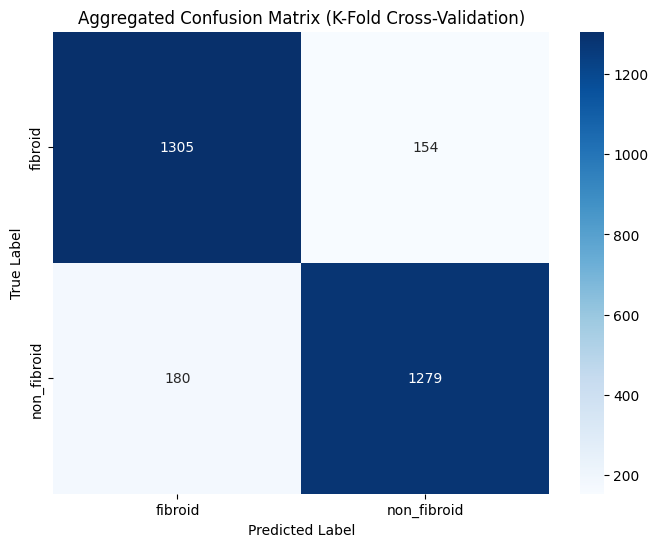

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

aggregated_conf_matrix = np.sum(fold_conf_matrices, axis=0)

plt.figure(figsize=(8, 6))
sns.heatmap(aggregated_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_dataset.classes, yticklabels=train_dataset.classes)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Aggregated Confusion Matrix (K-Fold Cross-Validation)')
plt.show()